# IS4487 Week 4 - Assignment

### Outline

Our Goals with this Project:

1. Import and review the data
2. Perform EDA and Clean Data

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_4_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### AdviseInvest Data Dictionary

| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |


### Load Libraries

Import the libraries you will need, such as:
- Pandas
- Sklearn
- Matplotlib


In [2]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

## Step 1: Initial Data Understanding

 - Import data from the AdviseInvest historical dataset into a dataframe (in GitHub go to Assignments > DataSets)
 - Describe or profile the dataframe
 - Look for any outliers, missing values, or duplicates

In [3]:
# Import data from the AdviseInvest historical dataset into a dataframe
url = "https://raw.githubusercontent.com/dallinbenson/Fall-2025-IS-4487/refs/heads/main/DataSets/adviseinvest_historical_data.csv"
df = pd.read_csv(url)

# Display the first 5 rows of the dataframe
display(df.head())

,answered,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
0,1,13520,0,23,0,1,1,0,0.0,0,2,0,1,2
1,0,14780,0,22,2,1,0,1,0.0,3,0,3,0,0
2,1,37570,0,62,2,1,0,0,1.0,3,0,4,0,4
3,0,12450,0,33,2,1,0,1,0.0,1,0,2,0,0
4,0,12400,0,48,1,2,0,0,1.0,2,1,4,0,0


In [4]:
# Describe the dataframe
display(df.describe())

# Display information about the dataframe, including datatypes and non-null values
display(df.info())

,answered,income,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
count,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29502.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000
mean,0.546638,33766.893303,34.773454,1.915401,1.140998,0.210412,0.681128,0.240797,1.468547,0.956616,2.458345,0.091106,1.535792
std,0.497829,29379.202710,11.369865,0.658183,0.348025,0.407608,0.466047,0.427575,1.234727,1.483946,19.497380,0.287765,1.625916
min,0.000000,-65600.000000,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,13550.000000,26.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,1.000000,23310.000000,32.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000
75%,1.000000,41690.000000,40.000000,2.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,3.000000
max,1.000000,159450.000000,132.000000,3.000000,2.000000,1.000000,1.000000,1.000000,3.000000,4.000000,3345.000000,1.000000,4.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   answered        29504 non-null  int64  
 1   income          29504 non-null  int64  
 2   female          29504 non-null  object 
 3   age             29504 non-null  int64  
 4   job             29504 non-null  int64  
 5   num_dependents  29504 non-null  int64  
 6   rent            29504 non-null  int64  
 7   own_res         29504 non-null  int64  
 8   new_car         29502 non-null  float64
 9   chk_acct        29504 non-null  int64  
 10  sav_acct        29504 non-null  int64  
 11  num_accts       29504 non-null  int64  
 12  mobile          29504 non-null  int64  
 13  product         29504 non-null  int64  
dtypes: float64(1), int64(12), object(1)
memory usage: 3.2+ MB


None

In [5]:
# Check for missing values
print("Missing values per column:")
display(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:")
display(df.duplicated().sum())

# Check for outliers using descriptive statistics (already done in previous step, but can re-examine)
print("\nDescriptive statistics (for outlier detection):")
display(df.describe())

# You might want to visualize potential outliers for specific columns, e.g., using box plots for 'income' and 'age'
# plt.figure(figsize=(10, 5))
# plt.subplot(1, 2, 1)
# df.boxplot(column='income')
# plt.title('Box plot of Income')
# plt.subplot(1, 2, 2)
# df.boxplot(column='age')
# plt.title('Box plot of Age')
# plt.show()

Missing values per column:


,0
answered,0
income,0
female,0
age,0
job,0
num_dependents,0
rent,0
own_res,0
new_car,2
chk_acct,0



Number of duplicate rows:


np.int64(29035)


Descriptive statistics (for outlier detection):


,answered,income,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
count,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29502.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000
mean,0.546638,33766.893303,34.773454,1.915401,1.140998,0.210412,0.681128,0.240797,1.468547,0.956616,2.458345,0.091106,1.535792
std,0.497829,29379.202710,11.369865,0.658183,0.348025,0.407608,0.466047,0.427575,1.234727,1.483946,19.497380,0.287765,1.625916
min,0.000000,-65600.000000,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,13550.000000,26.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,1.000000,23310.000000,32.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000
75%,1.000000,41690.000000,40.000000,2.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,3.000000
max,1.000000,159450.000000,132.000000,3.000000,2.000000,1.000000,1.000000,1.000000,3.000000,4.000000,3345.000000,1.000000,4.000000


# Step 2: Exploratory Data Analysis (EDA)
- Explore the relationships between the target and independent variables
- Create at least five charts to show the relationships, using different chart types that are approriate to the analysis
- Ensure that all charts are clearly labeled and formatted

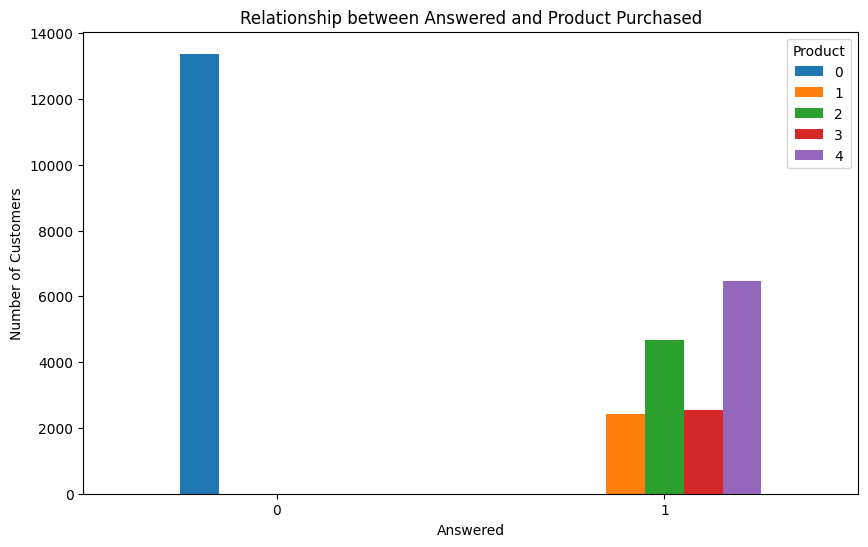

In [6]:
# Explore the relationship between 'answered' (independent) and 'product' (target)
# Create a cross-tabulation of 'answered' and 'product'
answered_product_xtab = pd.crosstab(df['answered'], df['product'])

# Plot a bar chart
answered_product_xtab.plot(kind='bar', figsize=(10, 6))
plt.title('Relationship between Answered and Product Purchased')
plt.xlabel('Answered')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0) # Keep x-axis labels horizontal
plt.legend(title='Product')
plt.show()

<Figure size 1000x600 with 0 Axes>

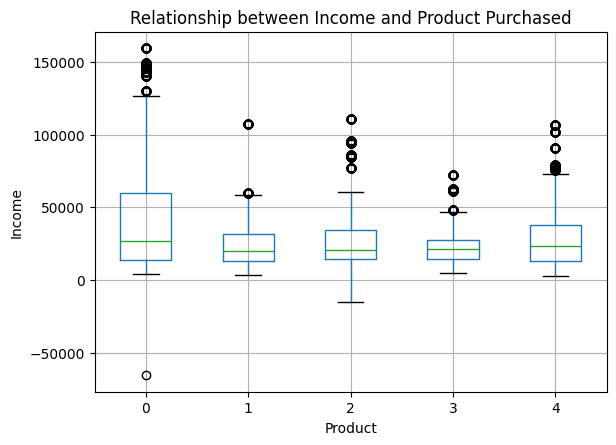

In [7]:
# Explore the relationship between 'income' (independent) and 'product' (target)
plt.figure(figsize=(10, 6))
df.boxplot(column='income', by='product')
plt.title('Relationship between Income and Product Purchased')
plt.suptitle('') # Suppress the default title
plt.xlabel('Product')
plt.ylabel('Income')
plt.show()

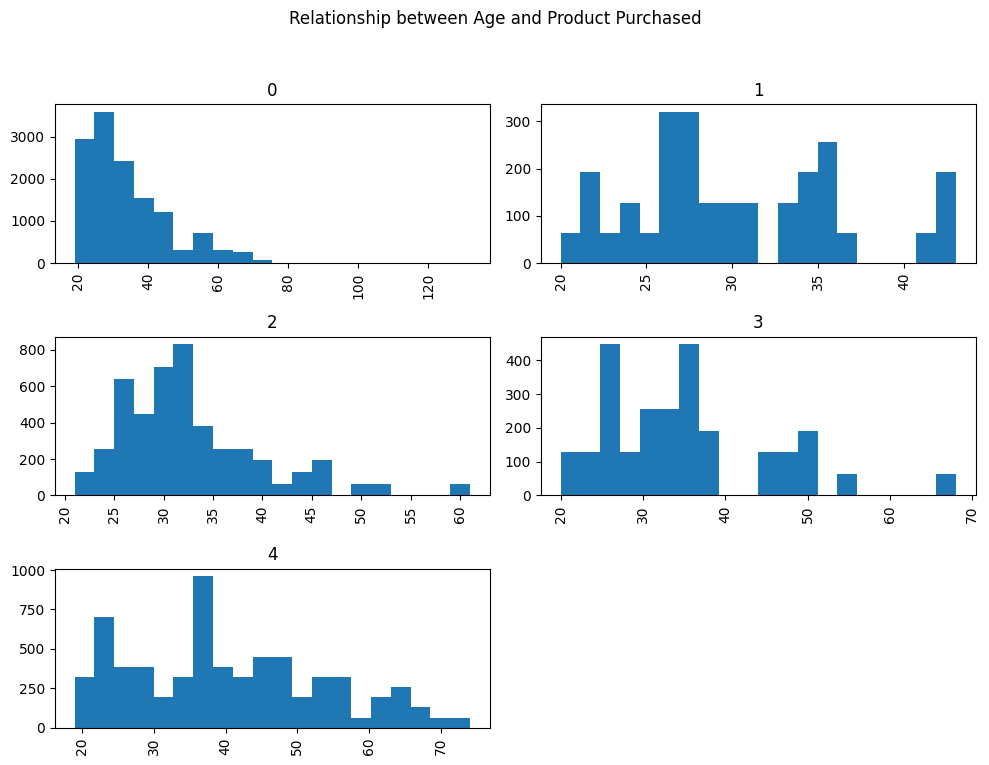

In [8]:
# Explore the relationship between 'age' (independent) and 'product' (target)
df.hist(column='age', by='product', bins=20, figsize=(10, 8))
plt.suptitle('Relationship between Age and Product Purchased')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

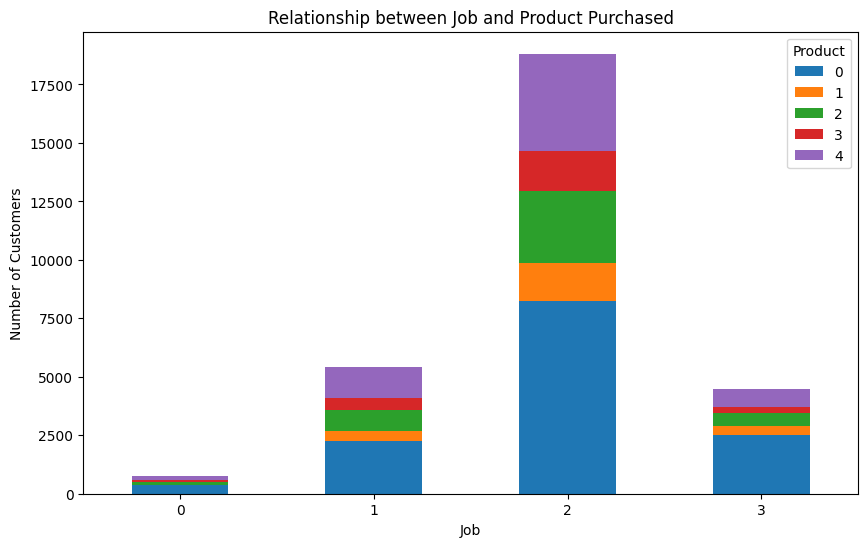

In [9]:
# Explore the relationship between 'job' (independent) and 'product' (target)
job_product_xtab = pd.crosstab(df['job'], df['product'])

# Plot a stacked bar chart
job_product_xtab.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Relationship between Job and Product Purchased')
plt.xlabel('Job')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0) # Keep x-axis labels horizontal
plt.legend(title='Product')
plt.show()

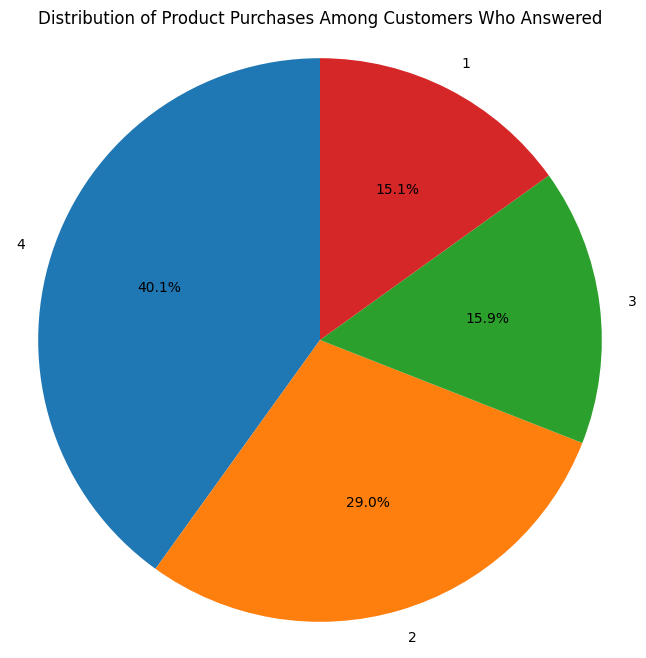

In [10]:
# Explore the relationship between 'product' (target) for customers who 'answered' (independent)
# Filter the dataframe to include only customers who answered the call ('answered' == 1)
answered_df = df[df['answered'] == 1]

# Get the value counts for the 'product' column in the filtered dataframe
product_counts = answered_df['product'].value_counts()

# Plot a pie chart
plt.figure(figsize=(8, 8))
plt.pie(product_counts, labels=product_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Product Purchases Among Customers Who Answered')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Step 3: Summarize Your Findings
### 3.1: Are all of the variables useful and applicable to the business need?  (you should reference the target variable and whether other variables have are likely to be correlated with the target)

I believe that all of the variables are useful and applicable to the business. I think that some of them are more useful than others, such as age, income, and if they answer the phone.

### 3.2: In what ways could the dataset be improved?  Are there any data quality issues or data types that should be fixed?

I think that the dataset could be improved by focusing more on the data that has the most correlation to the results, like income, age, and if they pickup the phone. Further research should be done into those categories in particular in order to find out what it is about those ages and income levels that makes it more likely.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas

In [12]:
!jupyter nbconvert --to html "assignment_04_BensonDallin.ipynb"

[NbConvertApp] Converting notebook assignment_04_BensonDallin.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 533044 bytes to assignment_04_BensonDallin.html
